# Fashion-MNIST brightness and contrast jitter (same batch, resampled)

Uses `make_fashion_mnist_dataloaders` from `inhibition/data.py`. Each row re-fetches the **same batch indices** through the dataset transform, so images stay fixed but `RandomAdjustBrightness` / `RandomAdjustContrast` draw anew. Contrast scales around each image's spatial mean, then brightness is applied.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from inhibition.data import make_fashion_mnist_dataloaders

In [2]:
DATA_DIR = "./data"
BRIGHTNESS_FACTOR = 0.75
BATCH_SIZE = 8
N_DRAWS = 4  # rows: same batch, new brightness each row

torch.manual_seed(23)

FMNIST_MEAN = 0.2860
FMNIST_STD = 0.3530

train_loader, _ = make_fashion_mnist_dataloaders(
    DATA_DIR,
    batch_size=BATCH_SIZE,
    test_batch_size=BATCH_SIZE,
    use_accel=True,
    brightness_factor=BRIGHTNESS_FACTOR,
    contrast_factor=0.0,
)

dataset = train_loader.dataset
batch_indices = list(range(BATCH_SIZE))  # first batch when use_accel=False (no shuffle)
targets = [dataset[i][1] for i in batch_indices]


def to_display(img: torch.Tensor) -> torch.Tensor:
    return (img * FMNIST_STD + FMNIST_MEAN).clamp(0.0, 1.0)

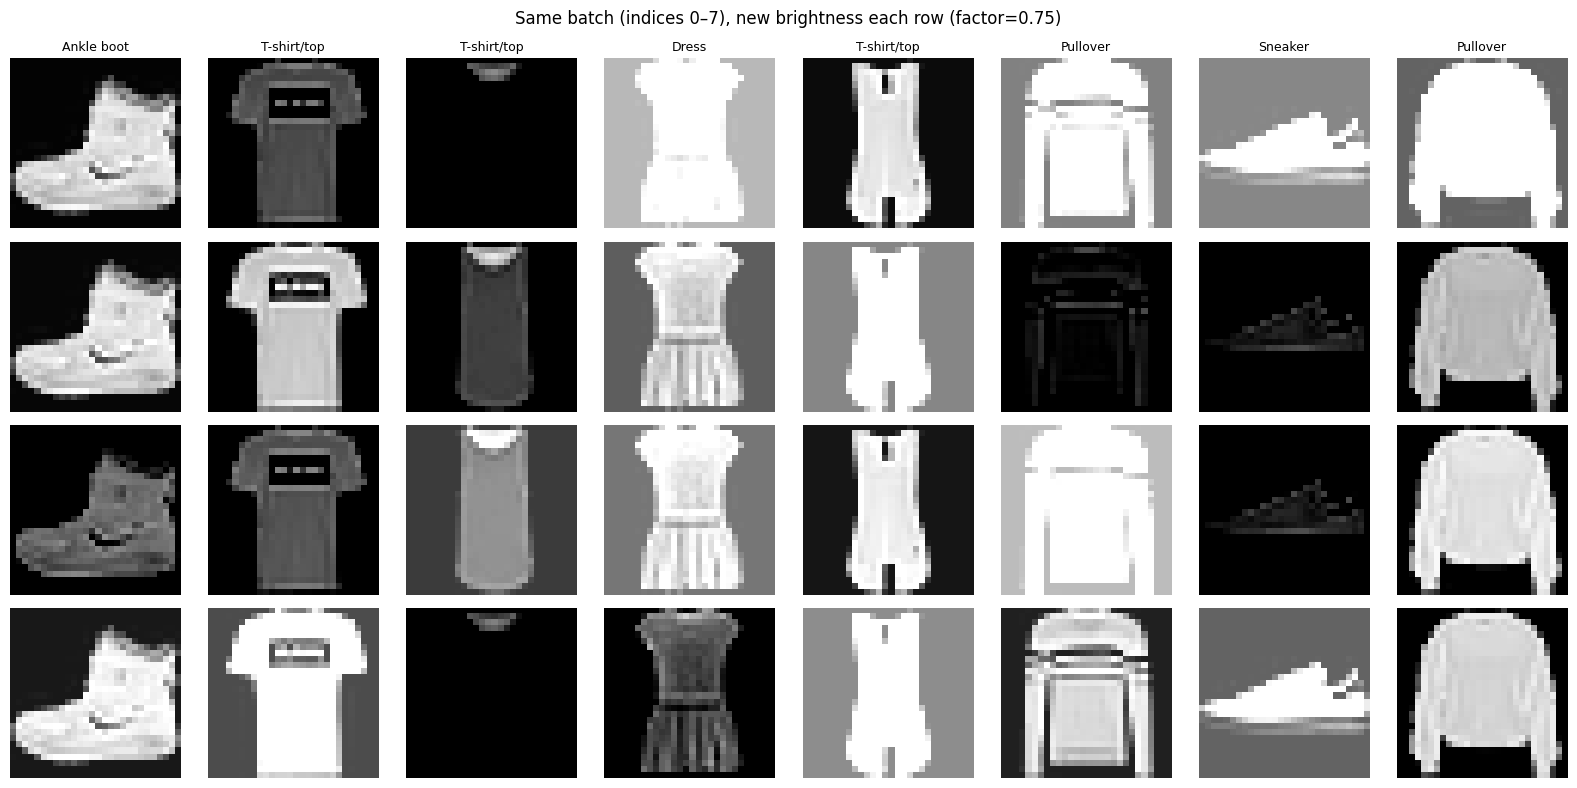

In [3]:
fig, axes = plt.subplots(N_DRAWS, BATCH_SIZE, figsize=(2 * BATCH_SIZE, 2 * N_DRAWS))
if N_DRAWS == 1:
    axes = axes.reshape(1, -1)

class_names = dataset.classes

for row in range(N_DRAWS):
    for col, idx in enumerate(batch_indices):
        img, _ = dataset[idx]
        axes[row, col].imshow(
            to_display(img).squeeze(0).numpy(),
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        if row == 0:
            axes[row, col].set_title(class_names[targets[col]], fontsize=9)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f"draw {row + 1}", fontsize=10)

fig.suptitle(
    f"Same batch (indices 0–{BATCH_SIZE - 1}), new brightness each row "
    f"(factor={BRIGHTNESS_FACTOR})",
    fontsize=12,
)
plt.tight_layout()
plt.show()

In [31]:
# Contrast jitter: same indices, brightness off
CONTRAST_FACTOR = 0.6

contrast_loader, _ = make_fashion_mnist_dataloaders(
    DATA_DIR,
    batch_size=BATCH_SIZE,
    test_batch_size=BATCH_SIZE,
    use_accel=True,
    brightness_factor=0.0,
    contrast_factor=CONTRAST_FACTOR,
)
contrast_dataset = contrast_loader.dataset

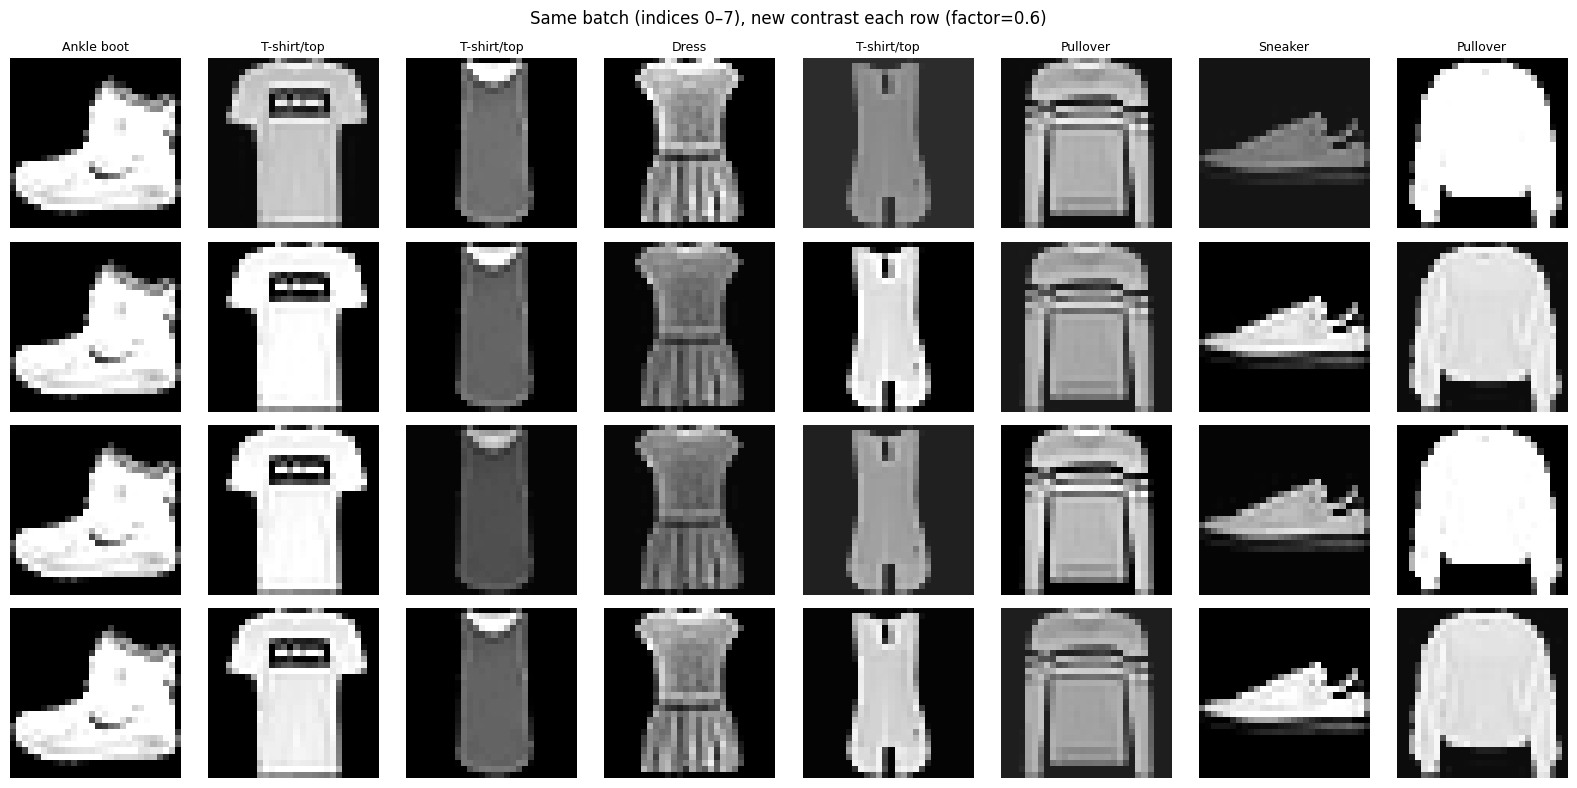

In [32]:
fig, axes = plt.subplots(N_DRAWS, BATCH_SIZE, figsize=(2 * BATCH_SIZE, 2 * N_DRAWS))
if N_DRAWS == 1:
    axes = axes.reshape(1, -1)

for row in range(N_DRAWS):
    for col, idx in enumerate(batch_indices):
        img, _ = contrast_dataset[idx]
        axes[row, col].imshow(
            to_display(img).squeeze(0).numpy(),
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        if row == 0:
            axes[row, col].set_title(class_names[targets[col]], fontsize=9)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f"draw {row + 1}", fontsize=10)

fig.suptitle(
    f"Same batch (indices 0–{BATCH_SIZE - 1}), new contrast each row "
    f"(factor={CONTRAST_FACTOR})",
    fontsize=12,
)
plt.tight_layout()
plt.show()